<style>
    .input_area, .output_area, pre, code {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

import sqlite3 as db

import importlib
import sys

if 'trainTestSplit' in sys.modules:
    del sys.modules['trainTestSplit'] #remove cached version of trainTestSplit if it exists

sys.path.append("../src")
from trainTestSplit import get_reg_splits, modified_reg_splits

import scipy.stats as st
import statsmodels.api as sm 
import pylab as py 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, PredictionErrorDisplay
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFE

Load the dataset

In [2]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_df = pd.read_sql_query("SELECT * FROM master", conn)

conn.close()

print(f"Data loaded successfully. Master dataset shape:, {master_df.shape[0]} records, {master_df.shape[1]} features.")
display(master_df.head())


Data loaded successfully. Master dataset shape:, 458 records, 23 features.


,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,race_white,race_hispanic,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,0.571876,-0.392703,-0.618768,1.897747,0.242736,-0.292939,0.376054,0.278606,0,0.581649
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,1.265442,-0.812366,-0.224057,-0.070897,9.043236,10.992720,9.194680,0.284134,0,3.480599
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,1.606091,-1.007781,-0.260578,-1.391047,-0.560484,-0.551553,-0.673864,0.151362,0,-0.618596
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-1.197404,-0.254952,-0.697429,-0.009136,-0.578973,-0.546764,-0.750563,0.313884,1,-0.264850
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,-1.057031,-0.429544,-0.791542,-0.541828,-0.078758,0.062656,-0.143792,0.633077,1,1.814352


Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = get_reg_splits(master_df)
print(f"Training set: {X_train.shape[0]} records, {X_train.shape[1]} features.")
print(f"Testing set: {X_test.shape[0]} records, {X_test.shape[1]} features.")

print("\n====Training set features:====\n")
for col in X_train.columns:
    print(f"{col}: {X_train[col].dtype}")

Training set: 343 records, 17 features.
Testing set: 115 records, 17 features.

====Training set features:====

household_income: float64
home_ownership: float64
rental_houses: float64
food_nutrition: float64
employment: float64
housing_age: float64
code_violations: float64
foreclosures: float64
new_constructions: float64
age_of_residents: float64
race_black: float64
race_hispanic: float64
race_asian: float64
race_other: float64
transit_proximity: float64
grocery_proximity: float64
crime_total: float64


Features with high VIF and Multicollinearity were already identified and handled during the data prep/EDA process. These features were dropped when setting up the multiple linear regression UDF for train test split. To expedite the feature selection, a Recursive Feature Elimination (RFE) will be ran to find the best combination of features based on Adjusted R². This is because RFE is best suited for a Multiple Linear Regression as it considers features that are individually weak, but collectively strong predictors... or individually strong but redundant with others.

In [4]:
lr = LinearRegression()

for k in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=lr, n_features_to_select=k)
    rfe.fit(X_train, y_train)

    X_selected = rfe.transform(X_train)

    r2_scores = cross_val_score(lr, X_selected, y_train, cv=8, scoring="r2")
    mean_r2 = r2_scores.mean()
    n, p = X_train.shape[0], k
    adj_r2 = 1 - (1 - mean_r2) * (n - 1) / (n - p - 1)
    
    selected = X_train.columns[rfe.support_].tolist()
    print(f"\nk={k}: Adj R²={adj_r2:.4f}")
    print(f"  Features: {selected}")


k=1: Adj R²=0.5919
  Features: ['home_ownership']

k=2: Adj R²=0.6911
  Features: ['household_income', 'home_ownership']

k=3: Adj R²=0.7085
  Features: ['household_income', 'home_ownership', 'food_nutrition']

k=4: Adj R²=0.7122
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents']

k=5: Adj R²=0.7137
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'race_asian']

k=6: Adj R²=0.7125
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian']

k=7: Adj R²=0.7095
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian', 'crime_total']

k=8: Adj R²=0.7070
  Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_asian', 'grocery_proximity', 'crime_total']

k=9: Adj R²=0.7061
  Features: ['household_income', 'home_ownership', 'fo

`race_asian` was selected by RFE multiple times. However, there's no theoretical justification for why it should be included. Also, given the sensitive nature of this project, I'm going to try to exclude it and run the RFE analysis again.

In [5]:
# Remove race_asian from X_train temporarily
X_train = X_train.drop(columns=["race_asian"])

lr = LinearRegression()
results = []

for k in range(1, X_train.shape[1] + 1):
    rfe = RFE(estimator=lr, n_features_to_select=k)
    rfe.fit(X_train, y_train)
    X_selected = rfe.transform(X_train)
    r2_scores = cross_val_score(lr, X_selected, y_train, cv=5, scoring="r2")
    mean_r2 = r2_scores.mean()
    n, p = X_train.shape[0], k
    adj_r2 = 1 - (1 - mean_r2) * (n - 1) / (n - p - 1)
    selected = X_train.columns[rfe.support_].tolist()
    print(f"k={k}: Adj R²={adj_r2:.4f} | Features: {selected}")

k=1: Adj R²=0.5981 | Features: ['home_ownership']
k=2: Adj R²=0.6989 | Features: ['household_income', 'home_ownership']
k=3: Adj R²=0.7143 | Features: ['household_income', 'home_ownership', 'food_nutrition']
k=4: Adj R²=0.7194 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents']
k=5: Adj R²=0.7185 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'grocery_proximity']
k=6: Adj R²=0.7182 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'age_of_residents', 'transit_proximity', 'grocery_proximity']
k=7: Adj R²=0.7187 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'transit_proximity', 'grocery_proximity']
k=8: Adj R²=0.7160 | Features: ['household_income', 'home_ownership', 'food_nutrition', 'new_constructions', 'age_of_residents', 'race_black', 'transit_proximity', 'grocery_proximity']
k=9: Adj R²=0.7160 | Features: ['household_income

After removing `race_asian`, the possible features associated with the highest Adj R² are more plausible explanations for `housing_cost_burden`.   
Adj R² also starts to decrease once more than four features are added. K-fold 5 includes:    
- `household_income` is an obvious direct measure of being able to afford housing.  
- `home_ownership` gives us insight on the stability of the population in the neighborhood
- `food_nutrition` is a proxy variable for poverty as a high food nutrition services is usually associated with lower income which equals higher burden
- `age_of_residents` older residents tend to be long term home owners with lower mortgage rates. Less younger populations tend to be an indicator of a dwindling quality of life.

However, we believe that the features for k=7, while having a slightly lower score, can tell a richer story.
- `new_construction` could indicate gentrification. Especially given Charlotte's population growth over the decades.  
- `transit_proximity` access to public transportation can affect housing costs. Too close and you're paying a lot for convenience. Too far makes it difficult to get around, especially commuting to a job.
- `grocery_proximity` food access, can be a proxy for urban development and population density.
  
The difference in scores is negligible. We think the penalty in the score is worth it for the addtional insight. 
A new train/test split will be created with these features in mind.


New Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = modified_reg_splits(master_df)

print(f"Modified Training set: {X_train.shape[0]} records, {X_train.shape[1]} features.")
print(f"Modified Testing set: {X_test.shape[0]} records, {X_test.shape[1]} features.")
print("\n====Modified Training set features:====\n")

for col in X_train.columns:
    print(f"{col}: {X_train[col].dtype}")

Modified Training set: 343 records, 7 features.
Modified Testing set: 115 records, 7 features.

====Modified Training set features:====

household_income: float64
home_ownership: float64
food_nutrition: float64
new_constructions: float64
age_of_residents: float64
transit_proximity: float64
grocery_proximity: float64


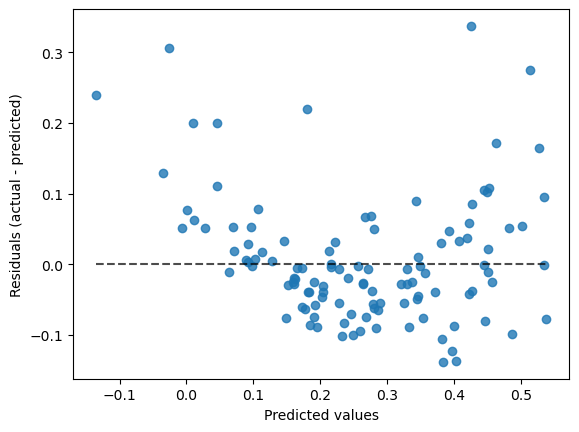

=== Multiple Linear Regression ===
R²:          0.6920
Adjusted R²: 0.6719
RMSE:        0.0892

Coefficients:
             feature  coefficient
2     food_nutrition     0.032615
4   age_of_residents     0.019609
5  transit_proximity     0.010647
3  new_constructions    -0.009636
6  grocery_proximity    -0.010303
0   household_income    -0.050749
1     home_ownership    -0.093872


In [7]:
# Fit the model on the modified training set
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Predictions
y_pred = mlr.predict(X_test)

res_plot = PredictionErrorDisplay(y_true=y_test, y_pred=y_pred)
res_plot.plot()
plt.show()

# Eval
r2 = r2_score(y_test, y_pred)
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
rmse = root_mean_squared_error(y_test, y_pred)

print("=== Multiple Linear Regression ===")
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")
print(f"RMSE:        {rmse:.4f}")

# Coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": mlr.coef_
}).sort_values("coefficient", ascending=False)

print("\nCoefficients:")
print(coef_df)

In [8]:
#OLS Regression with statsmodels

# Add constant
X2_train = sm.add_constant(X_train)

# Fit model
ols_model = sm.OLS(y_train, X2_train).fit()

# Predict
X2_test = sm.add_constant(X_test)
y_pred = ols_model.predict(X2_test)

# Summary
print(ols_model.summary())


                             OLS Regression Results                            
Dep. Variable:     housing_cost_burden   R-squared:                       0.736
Model:                             OLS   Adj. R-squared:                  0.730
Method:                  Least Squares   F-statistic:                     133.1
Date:                 Wed, 29 Apr 2026   Prob (F-statistic):           8.88e-93
Time:                         23:55:21   Log-Likelihood:                 357.12
No. Observations:                  343   AIC:                            -698.2
Df Residuals:                      335   BIC:                            -667.5
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2766

In [9]:
X_train_ols = X_train.drop(columns=["transit_proximity", "grocery_proximity"])
X_test_ols = X_test.drop(columns=["transit_proximity", "grocery_proximity"])

X2_train = sm.add_constant(X_train_ols)
X2_test = sm.add_constant(X_test_ols)

ols_model2 = sm.OLS(y_train, X2_train).fit()
print(ols_model2.summary())

                             OLS Regression Results                            
Dep. Variable:     housing_cost_burden   R-squared:                       0.734
Model:                             OLS   Adj. R-squared:                  0.730
Method:                  Least Squares   F-statistic:                     186.2
Date:                 Thu, 30 Apr 2026   Prob (F-statistic):           1.14e-94
Time:                         00:07:23   Log-Likelihood:                 356.22
No. Observations:                  343   AIC:                            -700.4
Df Residuals:                      337   BIC:                            -677.4
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2765

In [16]:
# Add interaction terms
X_train_int = X_train_ols.copy()
X_test_int = X_test_ols.copy()

# Theoretically meaningful interactions
X_train_int["income_x_ownership"] = X_train_ols["household_income"] * X_train_ols["home_ownership"] # does income affect burden differently for owners vs renters
X_train_int["income_x_nutrition"] = X_train_ols["household_income"] * X_train_ols["food_nutrition"] # low income + poor nutrition may exacerbate burden
# X_train_int["ownership_x_nutrition"] = X_train_ols["home_ownership"] * X_train_ols["food_nutrition"]
X_train_int["income_x_age"] = X_train_ols["household_income"] * X_train_ols["age_of_residents"] # income may have different impact on burden for younger vs older residents
X_train_int["ownership_x_age"] = X_train_ols["home_ownership"] * X_train_ols["age_of_residents"] # home ownership may affect burden differently for younger vs older residents

X_test_int["income_x_ownership"] = X_test_ols["household_income"] * X_test_ols["home_ownership"]
X_test_int["income_x_nutrition"] = X_test_ols["household_income"] * X_test_ols["food_nutrition"]
# X_test_int["ownership_x_nutrition"] = X_test_ols["home_ownership"] * X_test_ols["food_nutrition"]
X_test_int["income_x_age"] = X_test_ols["household_income"] * X_test_ols["age_of_residents"]
X_test_int["ownership_x_age"] = X_test_ols["home_ownership"] * X_test_ols["age_of_residents"]

# Fit OLS with interactions
X2_train_int = sm.add_constant(X_train_int)
X2_test_int  = sm.add_constant(X_test_int)

ols_int = sm.OLS(y_train, X2_train_int).fit()
print(ols_int.summary())

                             OLS Regression Results                            
Dep. Variable:     housing_cost_burden   R-squared:                       0.809
Model:                             OLS   Adj. R-squared:                  0.804
Method:                  Least Squares   F-statistic:                     156.7
Date:                 Thu, 30 Apr 2026   Prob (F-statistic):          4.93e-114
Time:                         00:48:28   Log-Likelihood:                 412.91
No. Observations:                  343   AIC:                            -805.8
Df Residuals:                      333   BIC:                            -767.4
Df Model:                            9                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2

In [17]:
# Drop new_constructions and refit with interactions
X_train_int2 = X_train_int.drop(columns=["new_constructions"])
X_test_int2 = X_test_int.drop(columns=["new_constructions"])

X2_train_int2 = sm.add_constant(X_train_int2)
X2_test_int2 = sm.add_constant(X_test_int2)

ols_int2 = sm.OLS(y_train, X2_train_int2).fit()
print(ols_int2.summary())

                             OLS Regression Results                            
Dep. Variable:     housing_cost_burden   R-squared:                       0.809
Model:                             OLS   Adj. R-squared:                  0.804
Method:                  Least Squares   F-statistic:                     176.7
Date:                 Thu, 30 Apr 2026   Prob (F-statistic):          4.11e-115
Time:                         00:48:36   Log-Likelihood:                 412.77
No. Observations:                  343   AIC:                            -807.5
Df Residuals:                      334   BIC:                            -773.0
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.2

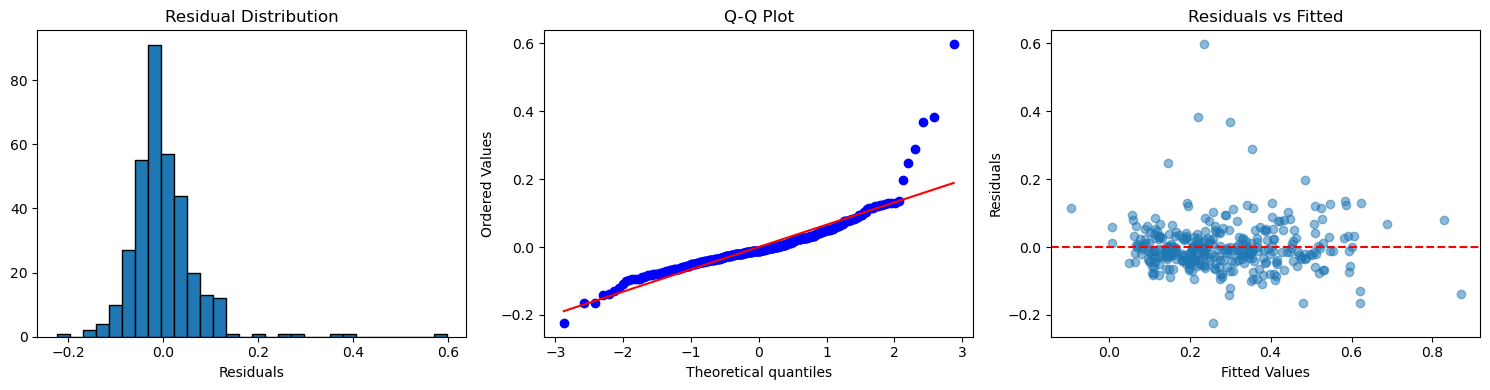


Outliers (|residual| > 3 std): 6
60    -0.223243
229    0.368263
198    0.288757
222    0.597451
37     0.382326
169    0.247717
dtype: float64


In [18]:
# Get residuals
residuals = ols_int2.resid

# Plot residual distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(residuals, bins=30, edgecolor="black")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residuals")

# Q-Q plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

# Residuals vs fitted
axes[2].scatter(ols_int2.fittedvalues, residuals, alpha=0.5)
axes[2].axhline(y=0, color="red", linestyle="--")
axes[2].set_title("Residuals vs Fitted")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

# Identify extreme outliers
outlier_threshold = 3 * residuals.std()
outliers = residuals[abs(residuals) > outlier_threshold]
print(f"\nOutliers (|residual| > 3 std): {len(outliers)}")
print(outliers)

In [14]:
outlier_idx = outliers.index

# Look up in master_df using original features
print(master_df.loc[outlier_idx, ["NPA", "household_income", "home_ownership", 
                                   "food_nutrition", "age_of_residents", 
                                   "housing_cost_burden"]])

     NPA  household_income  home_ownership  food_nutrition  age_of_residents  \
229  234         -0.907992        0.573681        0.772220         -0.862104   
198  202         -1.048112        0.252138        0.591117         -1.242258   
222  227         -0.630557        0.789230        0.141280          0.047549   
37    39         -0.303283        0.550903        0.281489          0.169741   
169  173          0.065368        0.619842        1.035111         -0.210413   

     housing_cost_burden  
229             0.667916  
198             0.643629  
222             0.832372  
37              0.602305  
169             0.394731  


In [ ]:
# Get original std of age_of_residents
conn = db.connect("../data/charlotte_housing.db")
qol_raw = pd.read_sql("SELECT NPA, age_of_residents FROM qol", conn)
conn.close()

age_std = qol_raw["age_of_residents"].std()

# Back-transform coefficient
scaled_coef = 0.0173  # from OLS output
actual_coef = scaled_coef / age_std

print(f"Original std: {age_std:.2f} years")
print(f"Scaled coefficient: {scaled_coef:.4f}")
print(f"Actual coefficient: {actual_coef:.6f}")
print(f"Interpretation: a 1-year increase in median age is associated with a {actual_coef:.4f} increase in housing cost burden")

Original std: 7.37 years
Scaled coefficient: 0.0173
Actual coefficient: 0.002346
Interpretation: a 1-year increase in median age is associated with a 0.0023 increase in housing cost burden
